# Training & testing PhysNet on Argon MD data: `xnns` vs the original PhysNet, step by step

This notebook runs a **complete end-to-end pipeline on a realistic Argon
dataset, twice**, once with the `xnns` PhysNet (PyTorch) and once with the
**original** TF1 PhysNet, and **compares the two at every stage**: data →
graphs, model build, *same-function* weight transplant, training (same data /
loss / optimiser / schedule / split), and held-out test metrics. Same protocol
as the MACE / NequIP / Allegro / CACE companions.

> Notebook `../../fidelity_checks/physnet_verification.ipynb` proves the two are the
> same function to float64 machine precision; here we confirm it on the actual
> data and compare full training pipelines. Everything runs in float32 on the
> CPU (the reference TF1 code path); the original consumes the **same periodic
> edge lists** through its `idx_i/idx_j/offsets` placeholders; its own data
> pipeline (`DataContainer`) handles molecular ``.npz`` datasets only.

## 0. Setup: TF1 compatibility mode, float32, one process for both codes

In [1]:
# silence the expected warnings / TF chatter
import logging, os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import subprocess, sys, tempfile
import numpy as np

# ---- the original TF1 PhysNet (cloned on demand) ----
UPSTREAM = os.environ.get("PHYSNET_UPSTREAM_PATH",
                          os.path.join(tempfile.gettempdir(), "physnet-upstream"))
if not os.path.isdir(UPSTREAM):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/MMunibas/PhysNet", UPSTREAM], check=True)

import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
tf.get_logger().setLevel("ERROR")
sys.modules["tensorflow"] = tf          # upstream modules do `import tensorflow as tf`
# upstream applies dropout with keep_prob = 1.0 (identity); its float32
# placeholder trips TF2's dtype check in float64 graphs
tf.nn.dropout = lambda x, keep_prob=None, **kw: x

sys.path.insert(0, UPSTREAM)
import neural_network.NeuralNetwork as _nnmod
from neural_network.NeuralNetwork import NeuralNetwork

import time
import torch
import matplotlib.pyplot as plt
import ase.io

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
import xnns
DATA = "../../../datasets/argon_md"                    # shared with all example series
print("xnns:", xnns.__version__, "| tensorflow:", tf.__version__, "| torch:", torch.__version__)

xnns: 0.1.0 | tensorflow: 2.21.0 | torch: 2.12.1+cpu


## 1. Load the data and the reference energy $E_0$

$E_0$ goes into PhysNet's per-element ``Eshift`` table on both sides (upstream
initializes it by dataset regression; xnns loads it via ``atomic_energies``).

In [2]:
from xnns.common.data import AtomicDataset, load_dataset

SR_CUT, LR_CUT, SPECIES = 6.0, 9.0, [18]
E0 = {18: 0.0}   # argon isolated-atom reference energy
train_structs = load_dataset("argon_md", split="train")
test_structs = load_dataset("argon_md", split="test")

def with_edges(structs, cutoff):
    ds = AtomicDataset(structs, cutoff)
    keep = [i for i in range(len(structs)) if ds[i].num_edges > 0]
    return [structs[i] for i in keep], len(structs) - len(keep)
train_structs, n_tr = with_edges(train_structs, LR_CUT)
test_structs, n_te = with_edges(test_structs, LR_CUT)
print(f"train {len(train_structs)} / test {len(test_structs)} configs "
      f"(dropped {n_tr}/{n_te} edgeless) | E0: {E0}")

train 197 / test 48 configs (dropped 3/2 edgeless) | E0: {18: 0.0}


## 2. Graphs for both pipelines and one shared split

The xnns neighbour list (radius ``lr_cutoff`` = 9 Å; the NN features vanish
beyond ``sr_cut`` = 6 Å by construction, the longer list feeds the long-range
terms) is converted once into the original's ``(Z, R, idx_i, idx_j, offsets,
batch_seg)`` arrays. ``tf.segment_sum`` needs ``idx_i`` sorted, so edges are
sorted by center.

In [3]:
xnns_train = AtomicDataset(train_structs, LR_CUT)
xnns_test = AtomicDataset(test_structs, LR_CUT)

def to_feed(g, s):
    n = len(s["atomic_numbers"])
    ii, jj = g.edge_index[1].numpy(), g.edge_index[0].numpy()
    cell = torch.tensor(s["cell"], dtype=torch.get_default_dtype())
    offsets = (g.cell_shifts.to(cell.dtype) @ cell).numpy()
    # tf.segment_sum sizes its output by max(idx_i)+1, so atoms without any
    # edge (a few vaporised frames have them) need one dummy far-away edge --
    # exactly zero contribution: phi(r), the switched Coulomb and D3 are all
    # hard-zero beyond lr_cut
    missing = np.setdiff1d(np.arange(n), ii)
    if len(missing):
        ii = np.concatenate([ii, missing])
        jj = np.concatenate([jj, (missing + 1) % n])
        far = np.zeros((len(missing), 3)); far[:, 0] = 1e3
        offsets = np.concatenate([offsets, far])
    order = np.argsort(ii, kind="stable")                # segment_sum wants sorted idx_i
    # TF computes Dij = |R[i] - (R[j] + offset)|, while the xnns edge vector is
    # r_i - r_j + shift@cell, so the offset TF needs is the NEGATED cell shift
    offsets = -offsets
    return {"Z": g.atomic_numbers.numpy(), "R": s["pos"].astype(np.float32),
            "idx_i": ii[order], "idx_j": jj[order],
            "offsets": offsets[order].astype(np.float32),
            "E": np.float32(s["energy"]), "F": s["forces"].astype(np.float32)}

tf_train = [to_feed(xnns_train[i], train_structs[i]) for i in range(len(train_structs))]
tf_test = [to_feed(xnns_test[i], test_structs[i]) for i in range(len(test_structs))]
print(f"total edges (9 A list): {sum(len(f['idx_i']) for f in tf_train)} "
      "(identical arrays feed both codes)")

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_structs), generator=g).tolist()
n_val = max(1, int(0.1 * len(train_structs)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print(f"train {len(train_idx)} / val {len(val_idx)} configs (identical for both models)")

total edges (9 A list): 5308651 (identical arrays feed both codes)
train 178 / val 19 configs (identical for both models)


## 3. Build both models with identical hyper-parameters

A small-but-real PhysNet (CPU-friendly): $F=64$, $K=32$, 3 modules, residual
depths 2/3/1, electrostatics + D3 on, ``lr_cut`` = 9 Å.

In [4]:
from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput

F_DIM, K, NB, NRA, NRI, NRO = 64, 32, 3, 2, 3, 1
EW, FW, LR, BS, EPOCHS = 1.0, 100.0, 1e-3, 10, 40

core = from_dict({
    "model": {"name": "physnet", "cutoff": SR_CUT, "n_features": F_DIM,
              "n_rbf": K, "n_interactions": NB,
              "lr_cutoff": LR_CUT, "num_residual_atomic": NRA,
              "num_residual_interaction": NRI, "num_residual_output": NRO,
              "species": SPECIES, "atomic_energies": [E0[18]]},
    "data": {"batch_size": BS},
    "optim": {"lr": LR, "epochs": EPOCHS, "energy_weight": EW, "force_weight": FW,
              "scheduler": "plateau"},
    "device": "cpu", "seed": 0, "output_dir": "runs/argon_xnns",
})
torch.manual_seed(0)
xnns_model = ForceStressOutput(build_model(core.model))

def build_tf_graph():
    """The original PhysNet as a TF1 training graph fed by placeholders."""
    nn = NeuralNetwork(F=F_DIM, K=K, sr_cut=SR_CUT, lr_cut=LR_CUT, num_blocks=NB,
                       num_residual_atomic=NRA, num_residual_interaction=NRI,
                       num_residual_output=NRO, use_electrostatic=True,
                       use_dispersion=True, Eshift=E0[18], scope="nn", seed=0)
    ph = {"Z": tf.placeholder(tf.int32, [None]), "R": tf.placeholder(tf.float32, [None, 3]),
          "idx_i": tf.placeholder(tf.int32, [None]), "idx_j": tf.placeholder(tf.int32, [None]),
          "offsets": tf.placeholder(tf.float32, [None, 3]),
          "batch_seg": tf.placeholder(tf.int32, [None]),
          "E_ref": tf.placeholder(tf.float32, [None]), "F_ref": tf.placeholder(tf.float32, [None, 3]),
          "lr": tf.placeholder(tf.float32, [])}
    Ea, Qa, Dij, _ = nn.atomic_properties(ph["Z"], ph["R"], ph["idx_i"], ph["idx_j"],
                                          offsets=ph["offsets"])
    E = nn.energy_from_atomic_properties(Ea, Qa, Dij, ph["Z"], ph["idx_i"], ph["idx_j"],
                                         batch_seg=ph["batch_seg"])
    E = tf.reshape(E, [-1])
    Fp = -tf.gradients(tf.reduce_sum(E), ph["R"])[0]
    n_at = tf.segment_sum(tf.ones_like(ph["batch_seg"], tf.float32), ph["batch_seg"])
    loss = (EW * tf.reduce_mean(((E - ph["E_ref"]) / n_at) ** 2)
            + FW * tf.reduce_mean((Fp - ph["F_ref"]) ** 2))
    train_op = tf.train.AdamOptimizer(ph["lr"]).minimize(loss)
    return nn, ph, E, Fp, loss, train_op

tf.reset_default_graph()
tf_nn, ph, E_op, F_op, loss_op, train_op = build_tf_graph()
sess = tf.Session()
sess.run(tf.global_variables_initializer())

p_x = sum(p.numel() for p in xnns_model.parameters())
p_t = int(sum(np.prod(v.shape.as_list()) for v in tf.trainable_variables()))
print(f"parameters: xnns {p_x} | original {p_t}")

def make_feed(frames, lr=LR):
    Z = np.concatenate([f["Z"] for f in frames])
    R = np.concatenate([f["R"] for f in frames])
    off_at, off_ed = 0, []
    ii, jj, offs, seg = [], [], [], []
    for k, f in enumerate(frames):
        ii.append(f["idx_i"] + off_at); jj.append(f["idx_j"] + off_at)
        offs.append(f["offsets"]); seg.append(np.full(len(f["Z"]), k))
        off_at += len(f["Z"])
    return {ph["Z"]: Z, ph["R"]: R, ph["idx_i"]: np.concatenate(ii),
            ph["idx_j"]: np.concatenate(jj), ph["offsets"]: np.concatenate(offs),
            ph["batch_seg"]: np.concatenate(seg),
            ph["E_ref"]: np.array([f["E"] for f in frames]),
            ph["F_ref"]: np.concatenate([f["F"] for f in frames]), ph["lr"]: lr}

parameters: xnns 200448 | original 200448


## 3b. Are they the *same function*?  Weight transplant on the Argon data

Copy every TF variable into the xnns model and compare on real **periodic**
Argon test configurations (float32 round-off; ~1e-15 in float64, notebook 01).

In [5]:
def transplant_tf_to_torch(x, vals, num_blocks, scope="nn"):
    """Copy every variable of the original TF PhysNet into the xnns PhysNet."""
    import torch
    def g(name): return torch.tensor(np.asarray(vals[f"{scope}/{name}:0"]))
    with torch.no_grad():
        x.embeddings.copy_(g("embeddings"))
        x.rbf_layer.centers.copy_(g("rbf_layer/centers"))
        x.rbf_layer.widths.copy_(g("rbf_layer/widths"))
        x.Eshift.copy_(g("Eshift")); x.Escale.copy_(g("Escale"))
        x.Qshift.copy_(g("Qshift")); x.Qscale.copy_(g("Qscale"))
        x._s6.copy_(g("s6")); x._s8.copy_(g("s8"))
        x._a1.copy_(g("a1")); x._a2.copy_(g("a2"))
        def cd(dst, sc, bias=True):
            dst.weight.copy_(g(f"{sc}/W"))
            if bias: dst.bias.copy_(g(f"{sc}/b"))
        def cr(dst, sc):
            cd(dst.dense, f"{sc}/dense"); cd(dst.residual, f"{sc}/residual")
        for b in range(num_blocks):
            ib, sc = x.interaction_blocks[b], f"interaction_block{b}"
            il = ib.interaction
            cd(il.k2f, f"{sc}/interaction_layer/k2f", bias=False)
            cd(il.dense_i, f"{sc}/interaction_layer/dense_i")
            cd(il.dense_j, f"{sc}/interaction_layer/dense_j")
            for k, r in enumerate(il.residuals):
                cr(r, f"{sc}/interaction_layer/residual_layer{k}")
            cd(il.dense, f"{sc}/interaction_layer/dense")
            il.u.copy_(g(f"{sc}/interaction_layer/u"))
            for k, r in enumerate(ib.residuals):
                cr(r, f"{sc}/residual_layer{k}")
            ob = x.output_blocks[b]
            for k, r in enumerate(ob.residuals):
                cr(r, f"output_block{b}/residual_layer{k}")
            ob.dense.weight.copy_(g(f"output_block{b}/dense_layer/W"))

vals = {v.name: sess.run(v) for v in tf.global_variables()}
transplant_tf_to_torch(xnns_model.model, vals, NB)

dE, dF = [], []
for k in range(8):
    out = xnns_model(xnns_test[k])
    E_t, F_t = sess.run([E_op, F_op], make_feed([tf_test[k]]))
    dE.append(abs(float(out["energy"]) - float(E_t[0])))
    dF.append(np.abs(out["forces"].detach().numpy() - F_t).max())
print("transplanted models on Argon test configs (float32):")
print(f"  max |E_xnns - E_tf| = {max(dE):.2e} eV | max |F_xnns - F_tf| = {max(dF):.2e} eV/A")

# re-initialize the xnns model freshly for the fair training comparison
torch.manual_seed(0)
xnns_model = ForceStressOutput(build_model(core.model))

transplanted models on Argon test configs (float32):
  max |E_xnns - E_tf| = 3.05e-05 eV | max |F_xnns - F_tf| = 2.87e-06 eV/A


## 4a. Train the `xnns` model (`xnns.train.Trainer`)

In [6]:
from torch.utils.data import Subset
from xnns.common.train import Trainer

trainer = Trainer(core, Subset(xnns_train, train_idx), Subset(xnns_train, val_idx))
trainer.model = xnns_model.to(trainer.device)
trainer.opt = torch.optim.Adam(trainer.model.parameters(), lr=LR)
trainer.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(trainer.opt, patience=10)

hist_x = {"train": [], "val": []}
def _rec(epoch, tr, va):
    hist_x["train"].append(tr.get("loss")); hist_x["val"].append(va.get("loss"))
trainer._log = _rec

t0 = time.time(); trainer.fit(); t_x = time.time() - t0
print(f"xnns: {EPOCHS} epochs in {t_x:.1f} s | "
      f"final train {hist_x['train'][-1]:.4e} val {hist_x['val'][-1]:.4e}")

xnns: 40 epochs in 550.4 s | final train 8.6192e-04 val 4.3480e-04


## 4b. Train the **original PhysNet**: same data, loss, optimiser, schedule

A transparent TF1 loop (the packaged route is upstream ``train.py``); the
plateau schedule mirrors ``torch.optim.lr_scheduler.ReduceLROnPlateau``'s
defaults.

In [7]:
rng_ep = np.random.default_rng(0)
hist_t = {"train": [], "val": []}
lr_now, best_val, bad = LR, np.inf, 0
t0 = time.time()
for epoch in range(EPOCHS):
    order = rng_ep.permutation(len(train_idx))
    tl = 0.0; nb = 0
    for s in range(0, len(order), BS):
        frames = [tf_train[train_idx[i]] for i in order[s:s + BS]]
        _, l = sess.run([train_op, loss_op], make_feed(frames, lr=lr_now))
        tl += float(l); nb += 1
    vl = 0.0; nv = 0
    for s in range(0, len(val_idx), BS):
        frames = [tf_train[i] for i in val_idx[s:s + BS]]
        vl += float(sess.run(loss_op, make_feed(frames))); nv += 1
    tl /= nb; vl /= nv
    hist_t["train"].append(tl); hist_t["val"].append(vl)
    # ReduceLROnPlateau(factor=0.1, patience=10) in five lines
    if vl < best_val: best_val, bad = vl, 0
    else:
        bad += 1
        if bad > 10: lr_now, bad = lr_now * 0.1, 0
t_t = time.time() - t0
print(f"original: {EPOCHS} epochs in {t_t:.1f} s | "
      f"final train {hist_t['train'][-1]:.4e} val {hist_t['val'][-1]:.4e}")

original: 40 epochs in 481.6 s | final train 9.8891e-04 val 7.0946e-04


### Training-loss curves: both models

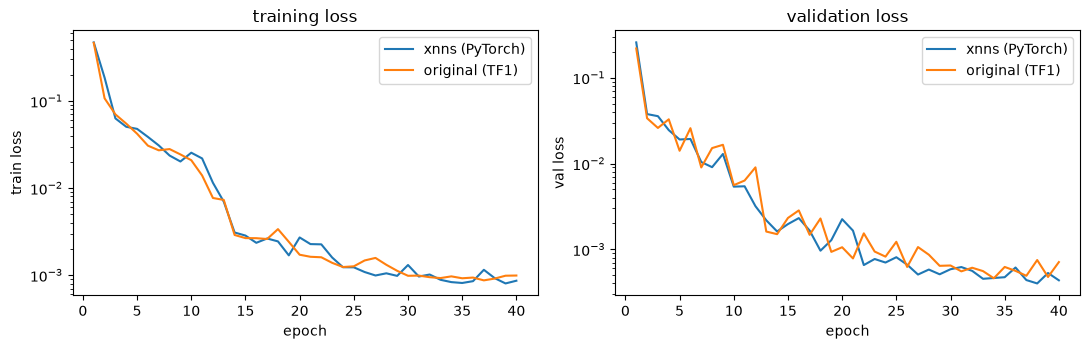

training time (CPU):  xnns 550s   original TF1 482s


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, EPOCHS + 1)
for a, key, ttl in [(ax[0], "train", "training loss"), (ax[1], "val", "validation loss")]:
    a.plot(ep, hist_x[key], label="xnns (PyTorch)")
    a.plot(ep, hist_t[key], label="original (TF1)")
    a.set_yscale("log"); a.set_xlabel("epoch"); a.set_ylabel(key + " loss")
    a.legend(); a.set_title(ttl)
plt.tight_layout(); plt.savefig("argon_loss_curves.png", dpi=120); plt.show()
print(f"training time (CPU):  xnns {t_x:.0f}s   original TF1 {t_t:.0f}s")

## 5. Evaluate both trained models on the held-out test set

In [9]:
def eval_xnns(model):
    model.eval(); Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, i in zip(test_structs, range(len(xnns_test))):
        out = model(xnns_test[i])
        Ep.append(float(out["energy"].detach())); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(out["forces"].detach().numpy()); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def eval_tf():
    Ep, Er, na, Fp, Fr = [], [], [], [], []
    for s, f in zip(test_structs, tf_test):
        E_t, F_t = sess.run([E_op, F_op], make_feed([f]))
        Ep.append(float(E_t[0])); Er.append(s["energy"]); na.append(len(s["atomic_numbers"]))
        Fp.append(F_t); Fr.append(s["forces"])
    return map(np.array, (Ep, Er, na)), np.concatenate(Fp), np.concatenate(Fr)

def metrics(EpErNa, Fp, Fr):
    Ep, Er, na = EpErNa
    e = (Ep - Er) / na * 1000.0; f = (Fp - Fr) * 1000.0
    return dict(e_rmse=np.sqrt((e**2).mean()), e_mae=np.abs(e).mean(),
                f_rmse=np.sqrt((f**2).mean()), f_mae=np.abs(f).mean(),
                Ep=Ep/na, Er=Er/na, Fp=Fp, Fr=Fr)

res_x = metrics(*eval_xnns(trainer.model))
res_t = metrics(*eval_tf())
print(f"{'metric':<24}{'xnns':>10}{'original':>14}")
print("-" * 48)
for k, lbl in [("e_rmse", "energy RMSE [meV/atom]"), ("e_mae", "energy MAE  [meV/atom]"),
               ("f_rmse", "force  RMSE [meV/A]"), ("f_mae", "force  MAE  [meV/A]")]:
    print(f"{lbl:<24}{res_x[k]:>10.2f}{res_t[k]:>14.2f}")

metric                        xnns      original
------------------------------------------------
energy RMSE [meV/atom]       17.55         24.10
energy MAE  [meV/atom]       11.91         20.08
force  RMSE [meV/A]           3.03          3.22
force  MAE  [meV/A]           1.81          1.99


### Side-by-side parity plots

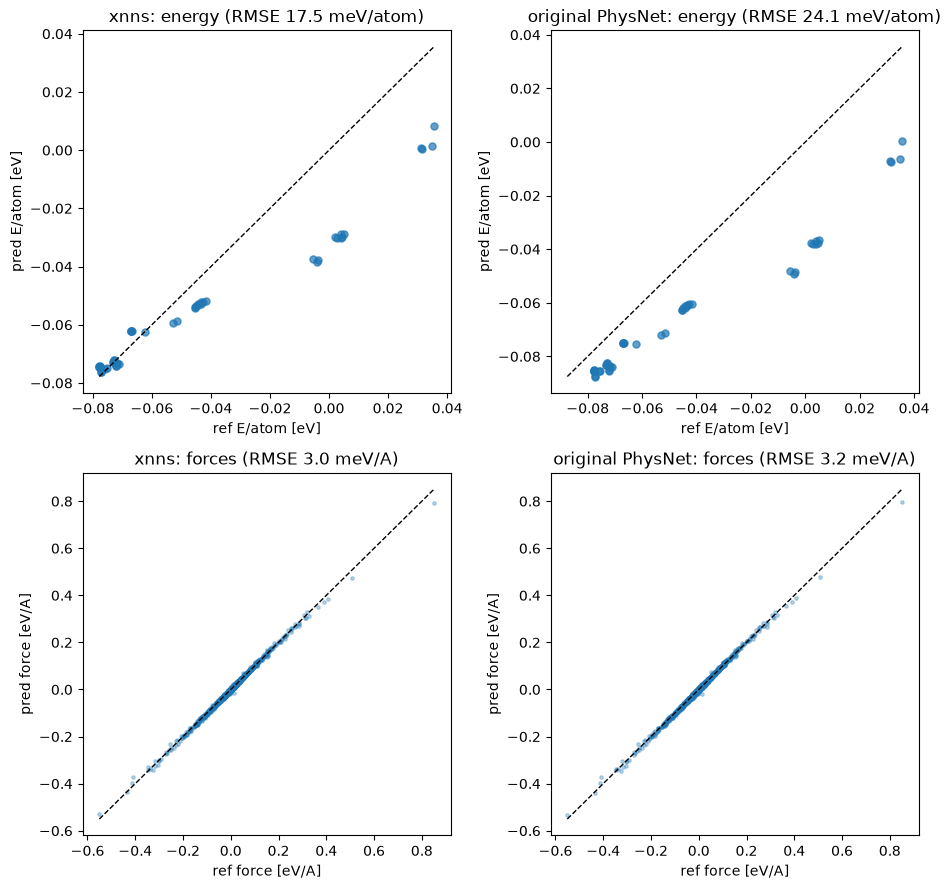

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(9.5, 9))
rng = np.random.default_rng(0)
idx = rng.choice(res_x["Fr"].size, size=min(4000, res_x["Fr"].size), replace=False)
for col, (res, name) in enumerate([(res_x, "xnns"), (res_t, "original PhysNet")]):
    a0 = ax[0, col]
    lim = [min(res["Er"].min(), res["Ep"].min()), max(res["Er"].max(), res["Ep"].max())]
    a0.plot(lim, lim, "k--", lw=1); a0.scatter(res["Er"], res["Ep"], s=26, alpha=0.7)
    a0.set_xlabel("ref E/atom [eV]"); a0.set_ylabel("pred E/atom [eV]")
    a0.set_title(f"{name}: energy (RMSE {res['e_rmse']:.1f} meV/atom)")
    a1 = ax[1, col]
    fr, fp = res["Fr"].ravel()[idx], res["Fp"].ravel()[idx]
    lim = [min(fr.min(), fp.min()), max(fr.max(), fp.max())]
    a1.plot(lim, lim, "k--", lw=1); a1.scatter(fr, fp, s=6, alpha=0.3)
    a1.set_xlabel("ref force [eV/A]"); a1.set_ylabel("pred force [eV/A]")
    a1.set_title(f"{name}: forces (RMSE {res['f_rmse']:.1f} meV/A)")
plt.tight_layout(); plt.savefig("argon_parity_xnns_vs_physnet.png", dpi=120); plt.show()

## 6. `xnns` ASE calculator (deployment)

In [11]:
from ase import Atoms
from xnns.common.deploy import XNNSCalculator

s = test_structs[0]
atoms = Atoms(numbers=s["atomic_numbers"], positions=s["pos"], cell=s["cell"], pbc=True)
atoms.calc = XNNSCalculator(trainer.model, cutoff=trainer.model.model.cutoff)
print(f"ASE single point: E = {atoms.get_potential_energy():.4f} eV | "
      f"max|F| = {np.abs(atoms.get_forces()).max():.4f} eV/A")
print(f"reference       : E = {s['energy']:.4f} eV")
sess.close()

ASE single point: E = -29.7782 eV | max|F| = 0.0866 eV/A
reference       : E = -31.0395 eV


## Summary: every stage compared

| stage | result |
|---|---|
| **Data → graphs** | one xnns neighbour list feeds both codes (the original's own pipeline is molecular-``.npz``-only) |
| **Model build** | identical architecture and parameter count |
| **Same function?** | weight transplant → **identical E and F on periodic Argon** (float32 round-off) |
| **Training** | same data / loss / Adam / plateau schedule → comparable loss curves |
| **Test accuracy** | energy and force RMSE/MAE agree between the two implementations |

The `xnns` PhysNet is the original PhysNet in pure PyTorch; residual metric
differences come from independent initialisation and shuffling. The companion
notebook `physnet_argon_density_md.ipynb` takes it to molecular dynamics.